In [2]:
import os
from pathlib import Path

# Função para detectar a raiz do projeto com base na presença de ".venv"
def find_project_root(max_depth=10):
    current = Path.cwd()
    for i in range(max_depth):
        if any((current / name).exists() for name in [".venv", "pyproject.toml", ".git"]):
            print(f"📁 Raiz do projeto encontrada: {current}")
            os.chdir(current)
            return current
        print(f"{i} - Subindo para: {current.parent}")
        current = current.parent
    raise RuntimeError("❌ Raiz do projeto não encontrada.")

# Executa a busca
project_root = find_project_root()

# Ativa autoreload para desenvolvimento dinâmico
%load_ext autoreload
%autoreload 2

0 - Subindo para: g:\py_projects\fast-english\app
1 - Subindo para: g:\py_projects\fast-english
📁 Raiz do projeto encontrada: g:\py_projects\fast-english


In [ ]:
# 1. Frequência de acerto
# - Quantas vezes o usuário acertou a palavra em jogos?
# - Qual a taxa de acerto (ex: 8 acertos em 10 tentativas = 80%)?

# 2. Recência
# - Quando foi a última vez que ele acertou essa palavra?
# - Palavras acertadas há muito tempo podem precisar de revisão.

# 3. Diversidade de contexto
# - Ele acertou essa palavra em diferentes tipos de jogos? (ex: forca, múltipla escolha, leitura)
# - Isso indica que ele entende a palavra em diferentes contextos.

# 4. Velocidade de resposta
# - Ele responde rápido quando vê essa palavra?
# - Respostas rápidas indicam fluência

# 5. Erro persistente
# - Ele erra essa palavra repetidamente, mesmo após várias exposições?
# - Isso indica que ele ainda não assimilou.

# 🧠 Ideias Futuras
# - Análise por tema: agrupar palavras por categorias (ex: animais, verbos, sentimentos).
# - Sugestões de reforço: retornar palavras com score baixo para revisão.
# - Histórico de evolução: mostrar como o domínio de uma palavra mudou ao longo do tempo.


from app.stats_words.analyzer import MasteryAnalyzer

# word_stats_analyzer = WordStatsAnalyzer(list_game_name=["game_data_hangman", "game_data_word_shuffle_game"])
# df = word_stats_analyzer.stats_grouped
# word_accuracy_map = dict(zip(df['word'].str.lower(), df['acuracia']))

# word_stats_analyzer = WordLearningAnalyzer(word_stats_analyzer.stats_grouped)


analyzer = MasteryAnalyzer()
df_mastery_report = analyzer.generate_report(
    "database/infos/game_data_word_shuffle_game.csv",
    "database/infos/game_data_hangman.csv"
)

In [5]:
import pandas as pd

list_words = [
    "i have a cat",
    "but i don't say"
]

df_phrase_mastery = analyzer.analyze_phrase_mastery(list_words, df_mastery_report)

In [6]:
df_phrase_mastery

,word,score,status
0,i,0.803,✅ Dominada
1,have,0.631,⚠️ Parcialmente
2,a,0.803,✅ Dominada
3,cat,0.000,❌ Não dominada
4,but,0.839,✅ Dominada
5,i,0.803,✅ Dominada
6,don't,0.517,⚠️ Parcialmente
7,say,0.460,❌ Não dominada


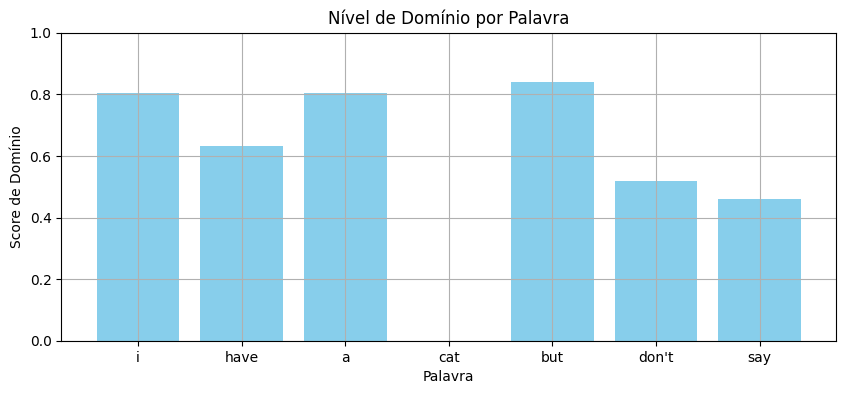

In [8]:
import matplotlib.pyplot as plt

def plot_mastery(df_phrase_mastery):
    plt.figure(figsize=(10, 4))
    plt.bar(df_phrase_mastery['word'], df_phrase_mastery['score'], color='skyblue')
    plt.ylim(0, 1)
    plt.title("Nível de Domínio por Palavra")
    plt.xlabel("Palavra")
    plt.ylabel("Score de Domínio")
    plt.grid(True)
    plt.show()

plot_mastery(df_phrase_mastery)

In [12]:
from app.toolkit.utils.data_loader import DataLoader as DataLoaderV1
from app.toolkit.word_engine.data_loader import DataLoader
from pathlib import Path

KIND = "phrases"
data_path = os.path.join("database", "extract_data_video", "data", "extracted_data", "{kind}", "data_organize")
data_loader = DataLoaderV1(base_path=data_path.format(kind=KIND))

data_structure = {}
content_types = ["words", "phrases", "personalized"]

for content_type in content_types:
    loader = DataLoaderV1(base_path=data_path.format(kind=content_type))
    content_data = {}

    for category in loader.get_categories():
        category_name = category.name
        category_data = {}

        for subcategory in loader.get_subcategories(category):
            subcategory_name = subcategory.name

            word_paths = [
                Path(str(path).replace("\\", "/"))
                for path in loader.get_word_paths(subcategory)
            ]

            category_data[subcategory_name] = word_paths

        content_data[category_name] = category_data

    data_structure[content_type] = content_data

In [13]:
word_list = data_structure["words"]["adjetivos"]["descição_de_arte"]

data_loader._carregar_palavra(word_list[0])

{'path': WindowsPath('database/extract_data_video/data/extracted_data/words/data_organize/adjetivos/descição_de_arte/aberrant'),
 'files': ['audio.wav',
  'audio.wav\uf03aZone.Identifier',
  'image_figure.jpg',
  'image_figure.jpg\uf03aZone.Identifier',
  'image_text.jpg',
  'image_text.jpg\uf03aZone.Identifier',
  'text_v2.json',
  'text_v2.json\uf03aZone.Identifier'],
 'text_pt_br': 'Aberrante | Extravagante',
 'text_eng': 'Aberrant',
 'status': 'revised',
 'audio_path': WindowsPath('database/extract_data_video/data/extracted_data/words/data_organize/adjetivos/descição_de_arte/aberrant/audio.wav'),
 'image_figure': WindowsPath('database/extract_data_video/data/extracted_data/words/data_organize/adjetivos/descição_de_arte/aberrant/image_figure.jpg')}

In [14]:
categories = data_structure["phrases"]

for i, (category_name, subcats) in enumerate(categories.items()):
    print(category_name, subcats)
    break

avião {'bagagem': [WindowsPath('database/extract_data_video/data/extracted_data/phrases/data_organize/avião/bagagem/are_you_checking_any_baggage'), WindowsPath('database/extract_data_video/data/extracted_data/phrases/data_organize/avião/bagagem/ay_baggage_ha_been_lost'), WindowsPath('database/extract_data_video/data/extracted_data/phrases/data_organize/avião/bagagem/can_i_pay_in_canadian_dollars'), WindowsPath('database/extract_data_video/data/extracted_data/phrases/data_organize/avião/bagagem/could_i_see_your_hand_baggage,_please'), WindowsPath('database/extract_data_video/data/extracted_data/phrases/data_organize/avião/bagagem/did_anyone_give_you_anything_to_carry'), WindowsPath('database/extract_data_video/data/extracted_data/phrases/data_organize/avião/bagagem/did_you_pack_your_bags_yourself'), WindowsPath('database/extract_data_video/data/extracted_data/phrases/data_organize/avião/bagagem/do_i_need_to_check_this_or_can_i_take_it_with_me'), WindowsPath('database/extract_data_video/

In [15]:

# path = 'database\\data\\words\\adjetivos\\dc31d7f0a2134fe4b6579ab8e921091e'
# os.listdir(path)

# load_words(Path(path))


In [16]:
subcats#.items()

{'bagagem': [WindowsPath('database/extract_data_video/data/extracted_data/phrases/data_organize/avião/bagagem/are_you_checking_any_baggage'),
  WindowsPath('database/extract_data_video/data/extracted_data/phrases/data_organize/avião/bagagem/ay_baggage_ha_been_lost'),
  WindowsPath('database/extract_data_video/data/extracted_data/phrases/data_organize/avião/bagagem/can_i_pay_in_canadian_dollars'),
  WindowsPath('database/extract_data_video/data/extracted_data/phrases/data_organize/avião/bagagem/could_i_see_your_hand_baggage,_please'),
  WindowsPath('database/extract_data_video/data/extracted_data/phrases/data_organize/avião/bagagem/did_anyone_give_you_anything_to_carry'),
  WindowsPath('database/extract_data_video/data/extracted_data/phrases/data_organize/avião/bagagem/did_you_pack_your_bags_yourself'),
  WindowsPath('database/extract_data_video/data/extracted_data/phrases/data_organize/avião/bagagem/do_i_need_to_check_this_or_can_i_take_it_with_me'),
  WindowsPath('database/extract_dat

In [17]:

word_engine = DataLoader()
index = word_engine.load_index()
word_engine.get_categories()

# word_engine.map_subcategories_to_word_path()

set()

In [18]:

group = "words"

for i, category_name in enumerate(word_engine.get_categories(group=group)):
    print(category_name)
    break

verbos


In [19]:
# from app.stats_words.analyzer import WordStatsAnalyzer, WordLearningAnalyzer

# word_stats_analyzer = WordStatsAnalyzer(list_game_name=["game_data_hangman", "game_data_word_shuffle_game"])
# df = word_stats_analyzer.stats_grouped

# word_accuracy_map = dict(zip(df['word'].str.lower(), df['acuracia']))

# word_stats_analyzer = WordLearningAnalyzer(word_stats_analyzer.stats_grouped)

In [20]:
dict_categories_to_subcategories = word_engine.map_categories_to_subcategories(group = "words")
dict_subcategories_to_word_path = word_engine.map_subcategories_to_word_path(group = "words")
set_subcategory = dict_categories_to_subcategories.get(category_name, set())
filter_subcategory = {
    name: dict_subcategories_to_word_path.get(name)
    for name in set_subcategory
    if name in dict_subcategories_to_word_path
}

In [21]:
# for _, words_path in filter_subcategory.items():


In [22]:
dict_subcategories_to_word_path["compras_online"]

{'database\\data\\words\\compras\\2c289e026e2544bbb499a20a051b78d4',
 'database\\data\\words\\compras\\2d8468d0c9104e65bb4692ea57eeeaf5',
 'database\\data\\words\\compras\\2e34eee7790b49e0af877c9e28ac693c',
 'database\\data\\words\\compras\\336d86281a474465a04067857437377d',
 'database\\data\\words\\compras\\44ca5ed785d44e2bb5290b0e1c5acd84',
 'database\\data\\words\\compras\\49fe11ff2988498497ca971aed5c251d',
 'database\\data\\words\\compras\\5b46b1cb36154ef99c2038c970fb742c',
 'database\\data\\words\\compras\\71dd2c971b7043b38cf6380006b72ac3',
 'database\\data\\words\\compras\\811b2a0028a542a18c59f3fce02ed93c',
 'database\\data\\words\\compras\\85f4eec73d69452fbab785caafb887fa',
 'database\\data\\words\\compras\\a590ec24f9df4c798409bc5629753e82',
 'database\\data\\words\\compras\\b9ded970e36d406c8e0fb4d15ad8c5f1',
 'database\\data\\words\\compras\\bbc84b1e60314ec4a12bce6ee1a130b8',
 'database\\data\\words\\compras\\c7152a96832740de805ca0697ec1c01a',
 'database\\data\\words\\compras\\

In [23]:
sum(len(words) for words in filter_subcategory.values())

426

In [24]:
[len(words) for words in filter_subcategory.values()]

[41, 38, 25, 50, 24, 20, 34, 22, 50, 43, 79]

In [25]:
teste = {"teste"}


teste.update(set(["teste2"]))

teste

{'teste', 'teste2'}

In [26]:
dict_categories_to_subcategories = word_engine.map_categories_to_subcategories()

In [27]:
# word_engine.map_subcategories_to_word_path()

In [28]:
# Criar exercicios de 20 a 20 
# Se determinado grupo tiver mais de 5 grupos deve-se ter um ...

In [29]:
import os
import json
from pathlib import Path
from collections import defaultdict

# Caminho da pasta onde estão os arquivos de vocabulário salvos
SAVE_FOLDER = Path("database/vocabulary/save_words")
database_files = list(SAVE_FOLDER.glob("*.json"))

def load_word_paths(json_path: Path) -> list:
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)

def split_into_sessions(word_paths: list, session_size: int = 30) -> dict:
    sessions = defaultdict(list)
    for idx, word_path in enumerate(word_paths):
        session_number = (idx // session_size) + 1
        sessions[session_number].append(word_path)
    return dict(sessions)

# Exemplo de uso
selected_file = database_files[1]
word_paths = load_word_paths(selected_file)
sessions = split_into_sessions(word_paths)

# Visualização
for session, paths in sessions.items():
    print(f"\n📚 Sessão {session} ({len(paths)} palavras):")
    for path in paths:
        print("  -", path)


📚 Sessão 1 (30 palavras):
  - database\data\words\verbos\a8d0970b856c4265847711bdaacb713a
  - database\data\words\verbos\cdd3b01599674f8f83a43135738d9280
  - database\data\phrases\avião\08a34fdf4d8f4832986b4f4e0e74f39b
  - database\data\words\corpo\cb572766016e45768f1caf947aa14c94
  - database\data\words\verbos\4bef9a8aea2e4dbba813a35b0b09f1ce
  - database\data\phrases\educação\3ed8ab59d15b490aad0e7129f5282caf
  - database\data\words\outras_partes_do_discurso\57f8371705e04214acbb285270e53af0
  - database\data\phrases\conversa_geral\bb4912b19a384e5ebd4ca7fdc1bec096
  - database\data\phrases\conversa_geral\e999095d25014068afe7a7ef592b1973
  - database\data\words\descrição_de_pessoas\313b142e13d849b4829bacdf7974bd9f
  - database\data\phrases\carro\ceba1b5f06ad49cc89dad2ea76f18ccf
  - database\data\phrases\compras\a272e0a8a2ae410a8458619ea138165f
  - database\data\words\outras_partes_do_discurso\2cc2541db6ba49139458a1226c8ce644
  - database\data\phrases\comida\c51ad84ae16d4baea18dd84115e7

In [30]:
len(sessions)

16

In [31]:
for i, category_path in enumerate(database_files):
    category_name = str(category_path).replace(".json", "").replace("database\\vocabulary\\save_words\\", "")
    print(i, category_name)

    word_paths = load_word_paths(category_path)
    sessions = split_into_sessions(word_paths)

    break

0 903_llm_benchmarks_update


In [32]:
from collections import defaultdict
from pathlib import Path

group = "words"
dict_category_subcategory_paths = defaultdict(lambda: defaultdict(list))

for idx in index:
    if idx["type"] == group:
        category = idx["category"]
        subcategory = idx["subcategory"]
        path = Path(idx["path"].replace("\\", "/"))  # Normaliza para WindowsPath

        dict_category_subcategory_paths[category][subcategory].append(path)

# Se quiser converter para dict padrão:
structured_dict = {cat: dict(subs) for cat, subs in dict_category_subcategory_paths.items()}